In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
data_dir = '/content/drive/MyDrive/RealWaste'


Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [3]:
IMG_HEIGHT = 160
IMG_WIDTH = 160
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())


Found 3803 images belonging to 9 classes.
Found 949 images belonging to 9 classes.


In [4]:
import numpy as np
labels = train_data.classes
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=labels)
class_weight_dict = dict(enumerate(class_weights))


In [17]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,037,504 (26.85 MB)

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=2,
                              verbose=1,
                              min_lr=1e-6)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 79s 542ms/step - accuracy: 0.1830 - loss: 2.3790 - val_accuracy: 0.4173 - val_loss: 1.6408 - learning_rate: 1.0000e-04
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 497ms/step - accuracy: 0.4174 - loss: 1.5984 - val_accuracy: 0.4974 - val_loss: 1.4104 - learning_rate: 1.0000e-04
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 72s 606ms/step - accuracy: 0.5522 - loss: 1.2464 - val_accuracy: 0.5385 - val_loss: 1.3182 - learning_rate: 1.0000e-04
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 487ms/step - accuracy: 0.5979 - loss: 1.0995 - val_accuracy: 0.5732 - val_loss: 1.2626 - learning_rate: 1.0000e-04
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 485ms/step - accuracy: 0.6290 - loss: 1.0069 - val_accuracy: 0.5817 - val_loss: 1.2027 - learning_rate: 1.0000e-04
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 478ms/step - accuracy: 0.6635 - loss: 0.9255 - val_accuracy: 0.5817 - val_loss: 1.2120 - learning_rate: 1.0000e-04
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 49

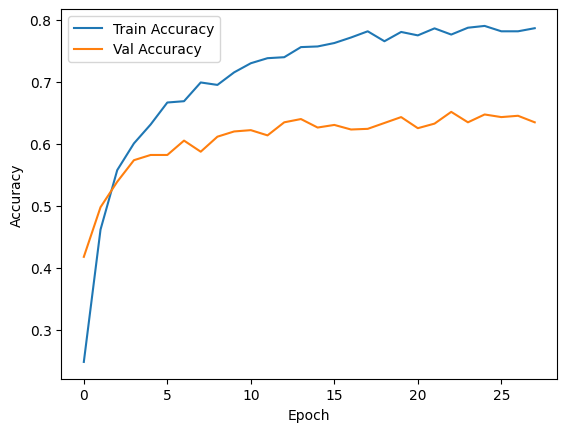

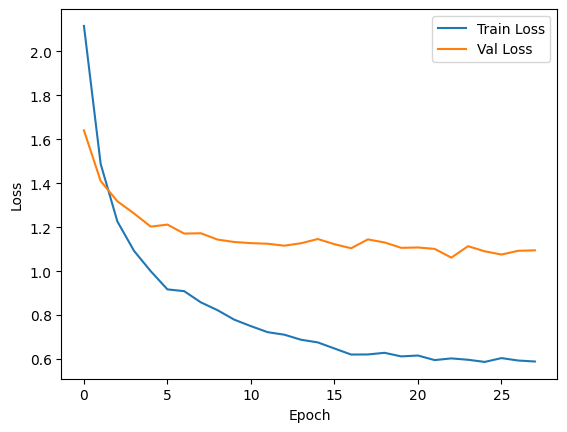

In [19]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
val_data.reset()
preds = model.predict(val_data)
predicted_classes = np.argmax(preds, axis=1)
true_classes = val_data.classes

print(classification_report(true_classes, predicted_classes, target_names=class_names))


30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 495ms/step
                     precision    recall  f1-score   support

          Cardboard       0.40      0.46      0.43        92
      Food Organics       0.85      0.90      0.88        82
              Glass       0.65      0.75      0.70        84
              Metal       0.64      0.73      0.68       158
Miscellaneous Trash       0.52      0.55      0.53        99
              Paper       0.68      0.61      0.64       100
            Plastic       0.64      0.42      0.51       184
      Textile Trash       0.55      0.67      0.60        63
         Vegetation       0.92      0.95      0.94        87

           accuracy                           0.64       949
          macro avg       0.65      0.67      0.66       949
       weighted avg       0.65      0.64      0.64       949



In [21]:
model.save("DenseNet121_waste_classifier.h5")


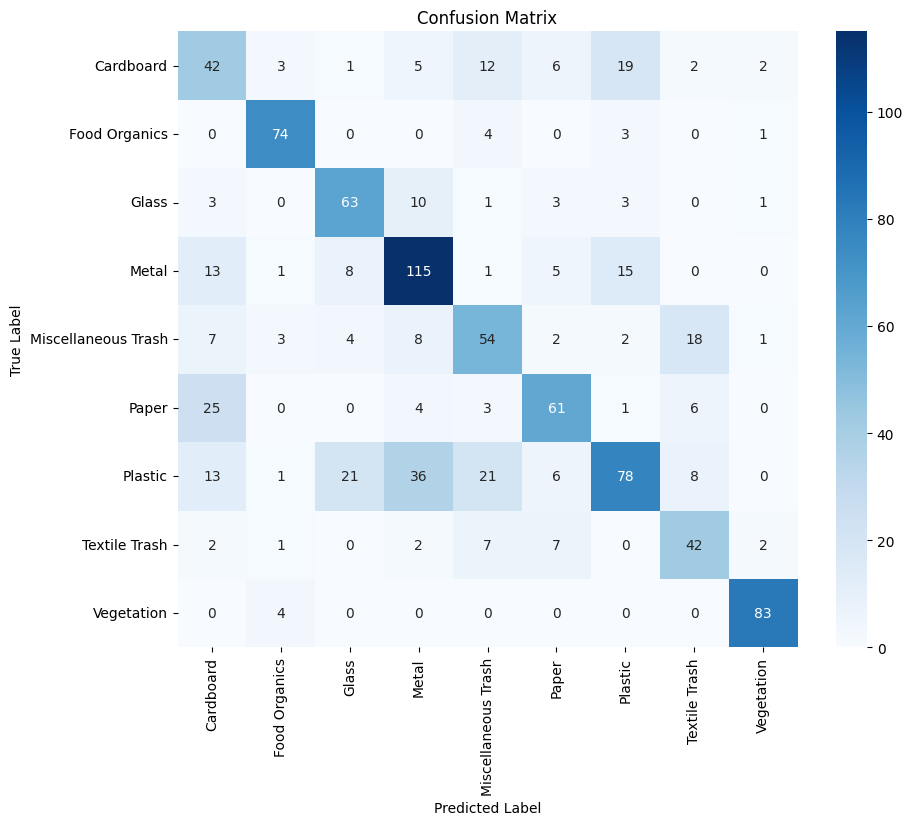

In [22]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
